# 🛍️ Customer Segmentation Using Clustering Algorithms

## 📖 Introduction
In this project, my goal is to segment customers into distinct groups based on their demographic data and purchasing behavior. By understanding these different customer profiles, businesses can tailor their marketing strategies more effectively.

Since there are no pre-defined labels for these groups, this is an **Unsupervised Learning** problem. I plan to explore the dataset, preprocess the features, and apply various clustering algorithms (such as K-Means, Hierarchical Clustering, and DBSCAN) to discover the most meaningful customer segments.



###  Importing Libraries

In this section, I am going to import the necessary libraries for data manipulation and data visualization.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

###  Loading the Dataset

Now, I will load the customer dataset into a Pandas DataFrame and display the first few rows to get an initial overview of the features.

In [3]:
# Load dataset
df = pd.read_csv("customer.csv")

# Display the first five rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


###  Exploratory Data Analysis (EDA)
####  Data Structure and Missing Values

In this section, I am going to check the data types of the features and look for any missing values. This is a crucial step to ensure data quality before applying any clustering algorithm.

In [4]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
# Check for missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

As observed from the output above, the dataset contains 200 entries and 5 columns. Fortunately, there are no missing values in any of the features, which means data imputation is not required. Additionally, all features are numerical except for the `Gender` column, which is a categorical string.

### 📈 Statistical Summary

Next, I will generate a statistical summary of the numerical features to understand their distribution, central tendency, and spread (such as min, max, and standard deviation). I will ignore the `CustomerID` column since it does not carry any analytical value.

In [6]:
# Show statistical summary without the ID column
df.drop('CustomerID', axis=1).describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


The statistical summary reveals some interesting insights. The customers' ages range from 18 to 70, with an average of around 39 years. The annual income spans from $15k to $137k, with a median of $61.5k. Interestingly, the spending score is perfectly centered, with both the mean and median resting at approximately 50. At first glance, the data scales seem reasonable and there are no obvious extreme outliers.

### 📊 Data Visualization: Feature Distributions

To get a better understanding of the data, I will visualize the distribution of both categorical and numerical features. I will start by plotting the `Gender` distribution using a count plot, followed by histograms for `Age`, `Annual Income`, and `Spending Score` to observe their shapes and identify any potential skewness.

C:\Users\technobist.ir\AppData\Local\Temp\ipykernel_13920\3154723759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


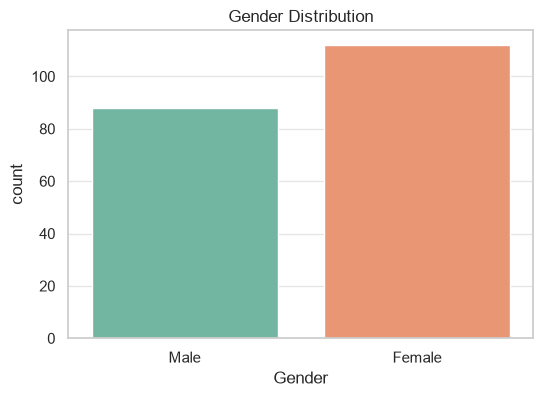

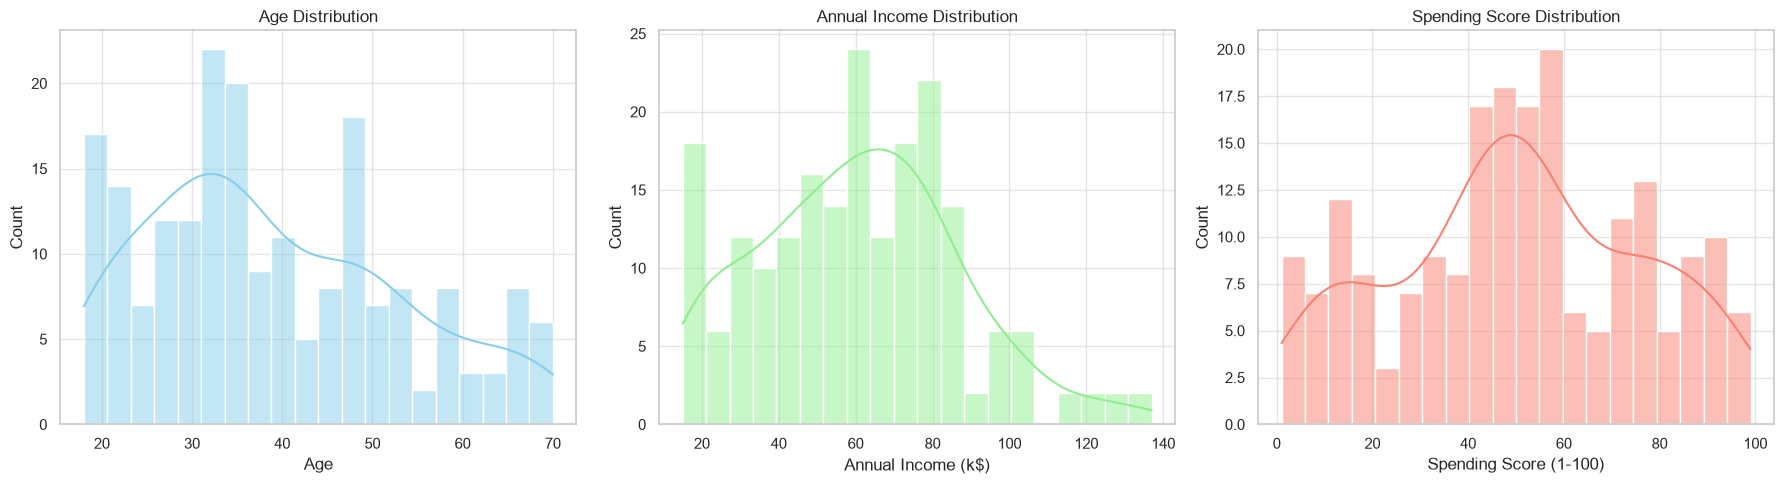

In [7]:
# Plot Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Gender Distribution')
plt.show()

# Plot histograms for numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

### 📊 Distribution Analysis

Based on the visualizations above, several key observations can be made:
- **Gender:** There is a slightly higher proportion of female customers compared to male customers.
- **Age:** The majority of the customers fall into the 20-40 age bracket, indicating a relatively young customer base.
- **Annual Income:** The income distribution is slightly right-skewed, with most customers earning between $50k and $80k annually.
- **Spending Score:** The spending score is normally distributed around the center, meaning the majority of customers exhibit average spending behavior (scores between 40 and 60).

### 🔗 Feature Relationships

Now, I will explore the relationships between different features using a pairplot. This visualization helps in identifying how variables interact with each other and whether any natural clusters are forming. I will color the data points based on `Gender` to observe if buying patterns differ between males and females.

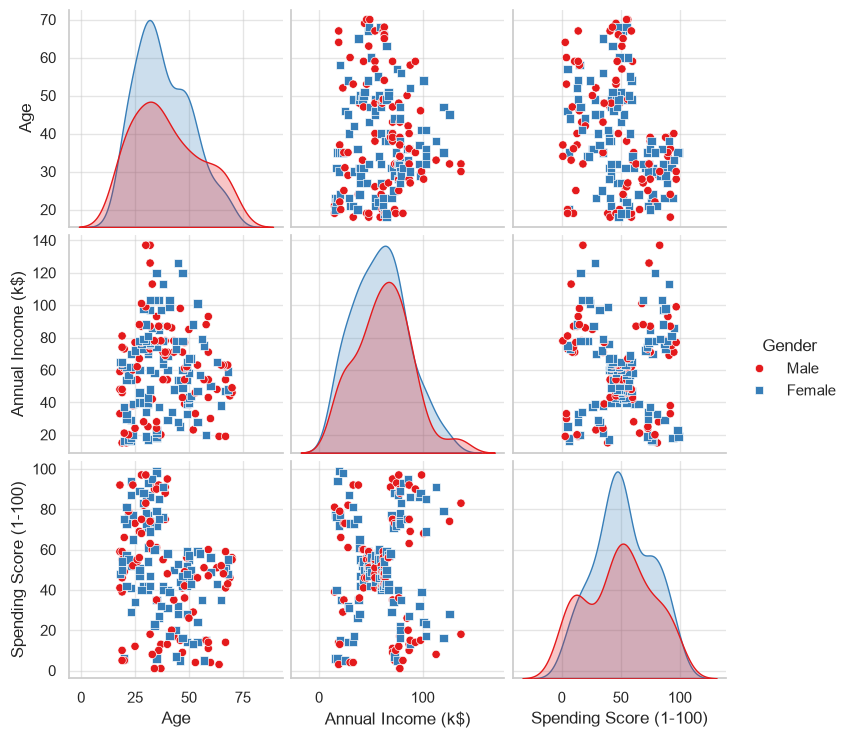

In [9]:
# Drop CustomerID as it has no analytical value
df_analysis = df.drop('CustomerID', axis=1)

# Plot pairwise relationships colored by Gender
sns.pairplot(df_analysis, hue='Gender', palette='Set1', markers=["o", "s"])
plt.show()

### 💡 Insights from Feature Relationships

Looking at the pairplot, the most striking observation is the relationship between `Annual Income` and `Spending Score`. We can clearly see five distinct clusters of customers forming naturally.
Additionally, analyzing `Age` versus `Spending Score` reveals that all customers with high spending scores (above 60) are younger than 40. Finally, the `Gender` variable is evenly distributed across these clusters, suggesting it might not be the primary driver for customer segmentation in this specific dataset.

### ⚙️ Data Preprocessing

Before applying clustering algorithms, the data must be properly preprocessed. Machine learning models, especially distance-based algorithms like K-Means, require numerical inputs and are sensitive to the scale of the data.
In this section, I will drop the unneeded `CustomerID` column, encode the categorical `Gender` feature into numerical values, and scale all features using `StandardScaler` so that they contribute equally to the distance calculations.

In [10]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Create a copy of the dataframe
df_processed = df.copy()

# Drop CustomerID column
df_processed = df_processed.drop('CustomerID', axis=1)

# Encode Gender column (Male/Female to numbers)
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])

# Scale the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_processed)

# Convert back to dataframe for readability
df_scaled = pd.DataFrame(scaled_data, columns=df_processed.columns)
display(df_scaled.head())

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


### 📐 Finding the Optimal Number of Clusters (Elbow Method)

To apply the K-Means algorithm, I first need to determine the optimal number of clusters (K). I will use the **Elbow Method**, which involves running K-Means for a range of K values (from 1 to 10) and calculating the Within-Cluster Sum of Squares (WCSS), also known as inertia.

By plotting these WCSS values against the number of clusters, I can identify the "elbow" point where the rate of decrease sharply slows down. This point typically represents the most balanced and optimal number of clusters for the dataset.

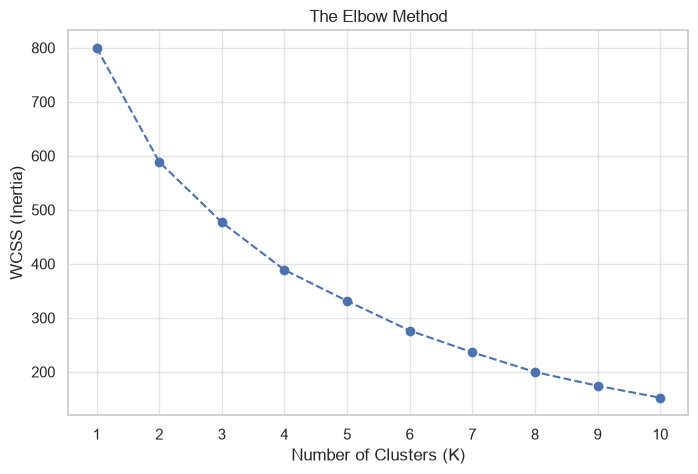

In [11]:
from sklearn.cluster import KMeans

# List to store the WCSS values
wcss = []

# Run K-Means for K values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

### 💡 Insights from the Elbow Method

Looking at the Elbow graph, the Within-Cluster Sum of Squares (WCSS) decreases rapidly as the number of clusters increases. However, the rate of decrease noticeably slows down after `K = 5`, creating an "elbow" shape. Combining this mathematical observation with the visual clusters identified earlier in the pairplot, `K = 5` is the optimal choice for our final K-Means model.

### 🤖 Final K-Means Model and Visualization

In this final step, I will initialize the K-Means algorithm with 5 clusters. After fitting the model and predicting the cluster labels for each customer, I will attach these labels to the original dataset. Finally, I will visualize the customer segments based on their `Annual Income` and `Spending Score` to extract actionable business insights.

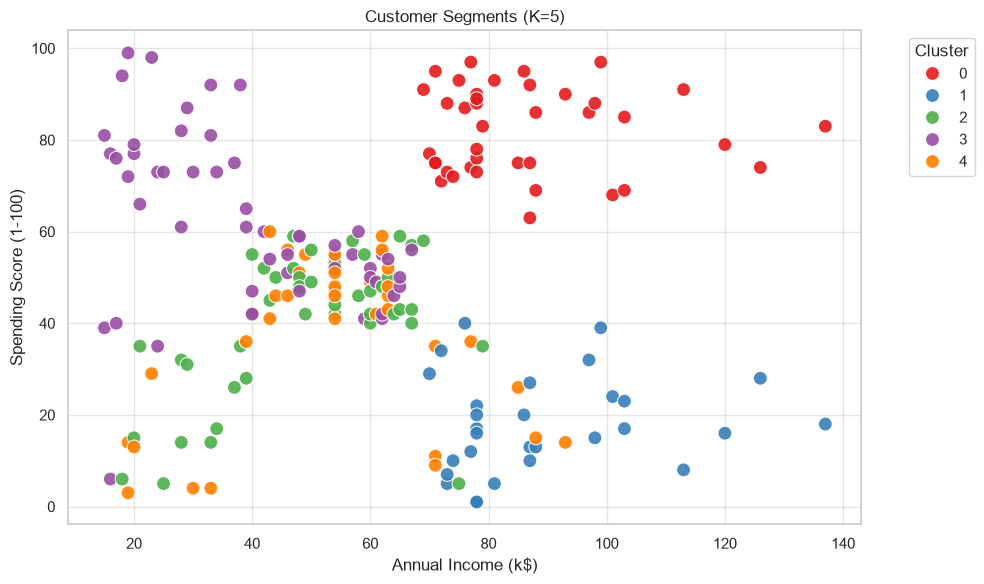

In [12]:
# Initialize K-Means with optimal K=5
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# Fit the model and predict the cluster for each data point
cluster_labels = kmeans_final.fit_predict(df_scaled)

# Add the cluster labels to our original (unscaled) dataframe
df['Cluster'] = cluster_labels

# Plot the final customer clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100,
    alpha=0.9
)

# Add titles and labels for better readability
plt.title('Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 💼 Business Insights and Customer Profiling

Although the 2D scatter plot above displays some overlapping segments, this occurs because our K-Means model formed clusters based on all available dimensions (Age, Gender, Income, and Spending Score).
To accurately profile each customer segment and uncover the underlying patterns, I will calculate the mean values of the numerical features for each individual cluster. This profiling allows the marketing team to understand exactly "who" belongs to each segment.

In [13]:
# Calculate the mean values for each cluster to profile the segments
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)

# Display the summary table
display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,32.69,86.54,82.13
1,36.48,89.52,18.00
2,49.81,49.23,40.07
3,24.91,39.72,61.20
4,55.71,53.69,36.77


### 🎯 Customer Profiling and Business Strategy

Based on the average values calculated above, we can clearly define the characteristics of each cluster and assign business-oriented names to them. This allows the marketing team to deploy highly targeted campaigns:

*   **Cluster 0 - "The Stars" (Target Customers):** Young adults (avg age 32) with high income and high spending scores. These are the most valuable customers and the primary target for premium and personalized marketing campaigns.
*   **Cluster 1 - "The Careful Savers":** Middle-aged adults (avg age 36) with the highest income but very low spending scores. They have high purchasing power but need targeted, value-driven promotions to be convinced to spend.
*   **Cluster 2 - "The Standard Audience":** Older adults (avg age 49) with average income and moderate spending. They represent a stable, baseline customer base that responds well to standard loyalty programs.
*   **Cluster 3 - "The Young Trendsetters":** The youngest demographic (avg age 24) with lower income but surprisingly high spending behavior. They likely spend on trends and are great targets for dynamic, youth-oriented, and social media marketing.
*   **Cluster 4 - "The Conservative Seniors":** The oldest group (avg age 55) with average income and low spending scores. They are careful with their budget and might respond best to discounts and essential goods promotions.

**🏆 Conclusion:**
By segmenting the customer base into these 5 distinct groups using the K-Means algorithm, the business can move away from a "one-size-fits-all" marketing approach. Instead, they can optimize their marketing budget by delivering the right message to the right audience, ultimately increasing the overall Return on Investment (ROI).

### 🌳 Hierarchical Clustering: Dendrogram

The next algorithm I will explore is **Hierarchical Clustering**. Unlike K-Means, this algorithm does not necessarily require specifying the number of clusters in advance.
To determine the optimal number of clusters for this approach, I will construct a **Dendrogram**. This visualization illustrates the hierarchical relationships between data points and helps identify the best threshold (distance) to cut the tree, effectively defining our distinct customer segments.

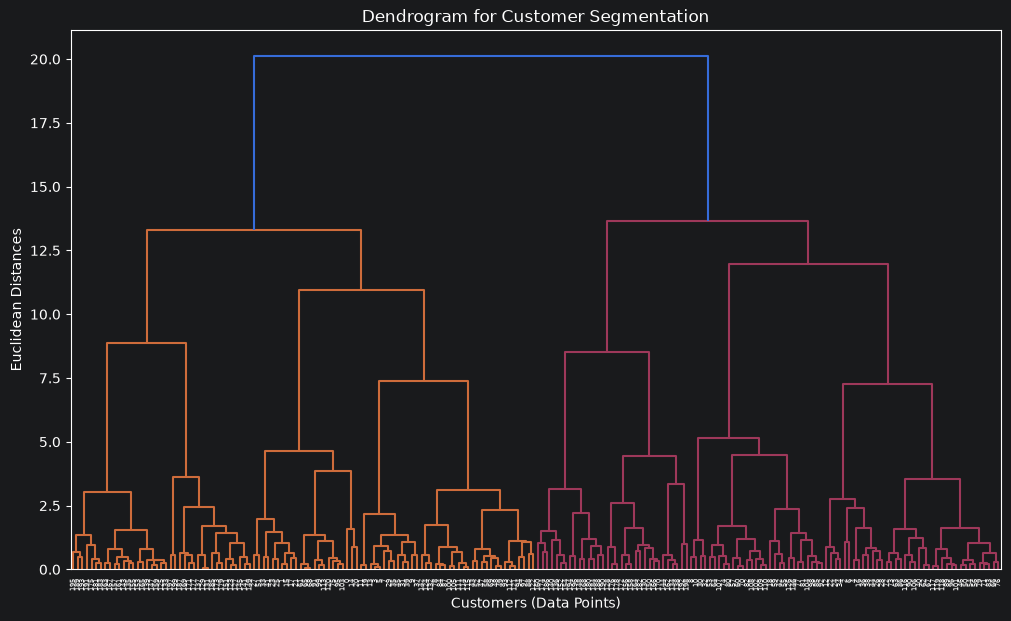

In [14]:
import scipy.cluster.hierarchy as sch

# Plot the dendrogram using the scaled data
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))

# Add titles and labels
plt.title('Dendrogram for Customer Segmentation')
plt.xlabel('Customers (Data Points)')
plt.ylabel('Euclidean Distances')
plt.show()

### ✂️ Determining Clusters and Applying Agglomerative Clustering

By analyzing the dendrogram, we look for the longest vertical lines to determine the optimal number of clusters. While the absolute longest vertical distance suggests 2 clusters, drawing a horizontal threshold line at a Euclidean distance of approximately `y = 11.5` intersects exactly 5 vertical lines.

This beautifully confirms the `K = 5` optimal clusters we identified earlier using the Elbow method. In this section, I will build the **Agglomerative Hierarchical Clustering** model with 5 clusters and visualize the resulting customer segments to compare them with the K-Means output.

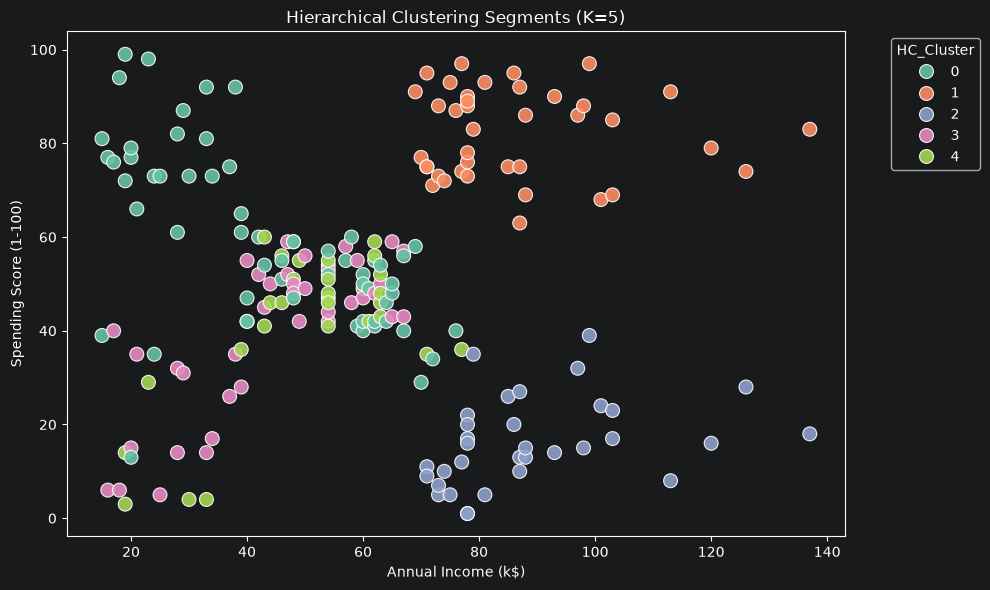

In [15]:
from sklearn.cluster import AgglomerativeClustering

# Initialize the Hierarchical Clustering model
hc_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')

# Fit the model and predict the cluster for each data point
hc_labels = hc_model.fit_predict(df_scaled)

# Add the new labels to our original dataframe
df['HC_Cluster'] = hc_labels

# Plot the final Hierarchical Clustering segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='HC_Cluster',
    data=df,
    palette='Set2',
    s=100,
    alpha=0.9
)

# Add titles and labels
plt.title('Hierarchical Clustering Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='HC_Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📊 Comparing Hierarchical Clustering with K-Means

Visualizing the results of the Agglomerative Hierarchical Clustering reveals a segmentation pattern that is highly consistent with our previous K-Means output.
The fact that two mathematically distinct algorithms (distance-based vs. linkage-based) converged on nearly identical customer segments strongly validates the inherent structure of our dataset. This consistency confirms that the 5 identified customer profiles are reliable for business decision-making.

### 🕵️‍♂️ Density-Based Clustering: DBSCAN

The final algorithm I will implement is **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise). Unlike K-Means and Hierarchical Clustering, DBSCAN does not force every single data point into a cluster. Instead, it groups densely packed data points and marks isolated points as outliers (noise).

This algorithm is particularly useful in real-world scenarios to identify irregular customer behaviors or anomalous purchasing patterns. I will define the neighborhood radius (`eps`) and the minimum number of points required to form a dense region (`min_samples`).

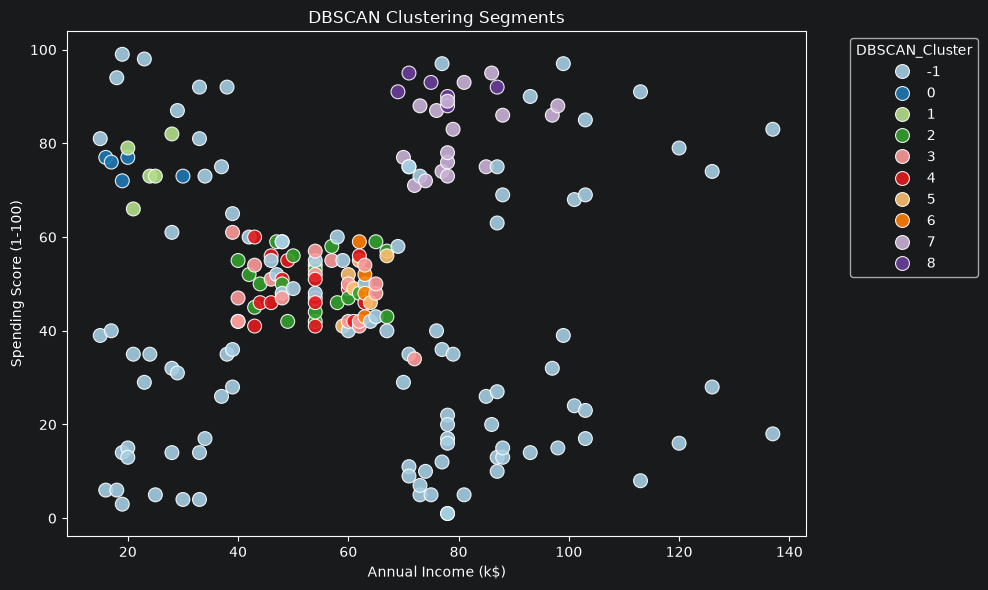

In [18]:
from sklearn.cluster import DBSCAN

# Initialize the DBSCAN model
# Note: eps=0.5 and min_samples=5 are standard starting points for scaled data
dbscan_model = DBSCAN(eps=0.5, min_samples=5)

# Fit and predict cluster labels
dbscan_labels = dbscan_model.fit_predict(df_scaled)

# Add DBSCAN labels to the original dataframe
df['DBSCAN_Cluster'] = dbscan_labels

# Plot the DBSCAN segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    data=df,
    palette='Paired',
    s=100,
    alpha=0.9
)

plt.title('DBSCAN Clustering Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='DBSCAN_Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📉 DBSCAN Insights and Final Project Conclusion

Looking at the DBSCAN output, the results are drastically different from K-Means and Hierarchical Clustering. The light blue points labeled as `-1` represent **noise (outliers)**. DBSCAN classified a significant portion of our customers, especially those on the outer edges (high/low income and spending), as noise because they do not meet the strict density requirements.

Furthermore, instead of finding 5 broad clusters, DBSCAN fragmented the dense central region into multiple smaller micro-clusters (labels 0 to 8). This happens because DBSCAN struggles with datasets that have varying densities.

#### 🏆 Final Verdict
While DBSCAN was excellent for identifying isolated, anomalous customer behaviors (the `-1` noise points), it failed to create actionable, broad marketing segments.

Both **K-Means** and **Agglomerative Hierarchical Clustering** successfully and consistently identified **5 distinct customer profiles**. For a business perspective, the **K-Means model is the winner** of this project. It provides clean, interpretable, and highly actionable segments that the marketing team can immediately use to personalize campaigns, optimize budgets, and increase customer retention.

### 🏅 Quantitative Model Evaluation

In unsupervised learning, we do not have ground truth labels to calculate metrics like Accuracy or Recall. Instead, we use intrinsic evaluation metrics to score and compare our clustering models.

In this final section, I will evaluate K-Means, Hierarchical Clustering, and DBSCAN using two standard metrics:
1. **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters (higher is better, max 1).
2. **Davies-Bouldin Index:** Measures the average similarity ratio of each cluster with its most similar cluster (lower is better).

In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Create a dictionary to store the evaluation scores
evaluation_metrics = {
    'Model': ['K-Means (K=5)', 'Hierarchical (K=5)', 'DBSCAN'],
    'Silhouette Score': [
        silhouette_score(df_scaled, cluster_labels),
        silhouette_score(df_scaled, hc_labels),
        silhouette_score(df_scaled, dbscan_labels)
    ],
    'Davies-Bouldin Index': [
        davies_bouldin_score(df_scaled, cluster_labels),
        davies_bouldin_score(df_scaled, hc_labels),
        davies_bouldin_score(df_scaled, dbscan_labels)
    ]
}

# Convert the dictionary into a Pandas DataFrame for a clean table
scores_df = pd.DataFrame(evaluation_metrics)

# Display the evaluation table rounded to 3 decimal places
display(scores_df.round(3))

,Model,Silhouette Score,Davies-Bouldin Index
0,K-Means (K=5),0.304,1.167
1,Hierarchical (K=5),0.287,1.220
2,DBSCAN,0.012,1.389


### 🏆 Final Evaluation and Model Selection

The quantitative evaluation table provides clear, mathematical proof to support our visual findings:

1. **K-Means (K=5)** is the undisputed winner. It achieved the highest Silhouette Score (0.304), indicating the most distinct and well-separated clusters, and the lowest Davies-Bouldin Index (1.167), meaning the clusters have the lowest similarity to each other.
2. **Hierarchical Clustering (K=5)** performed very closely to K-Means, proving that our `K=5` choice was robust, but it slightly lagged behind in both metrics.
3. **DBSCAN** had the poorest performance for this specific dataset (Silhouette Score near zero). This mathematically validates our earlier observation that DBSCAN struggles with the varying densities of these customer segments.

**Project Conclusion:**
For this customer segmentation task, **K-Means Clustering** is the most highly recommended model. It successfully grouped the customers into 5 actionable and mathematically validated segments, providing the marketing team with a reliable foundation for targeted strategies.

👨‍💻 Author

Created by Mehdi Ferdosi

Computer Science Student | Machine Learning Learner

⭐ Thanks for checking out this project